# Market-Making Simulator

In [1103]:
import numpy as np
import matplotlib.pyplot as plt


**Order Function** <br>
Generates a random buy or sell order around the true value of the asset with some noise

In [1104]:
def order(true_value):

#returns an order price dependent on the true value plus or minus some noise and randomly chooses buy/sell

    noise = np.random.normal(0,0.1) #mean = 0 stdev = 0.1
    order_price = true_value + noise

    direction = np.random.choice(['buy','sell'])

    return order_price, direction

**Price model** <br> Generates a random walk representing the asset's true value

In [1105]:
stdev = 0.01
t = np.arange(0,1000,1)
log_price = np.log(100)
log_true_value = []
log_true_value.append(log_price)
for i in range(len(t)-1):
    log_price += np.random.normal(0, stdev)
    log_true_value.append(log_price)

true_value = np.exp(log_true_value)



**Asset True Value Plot**

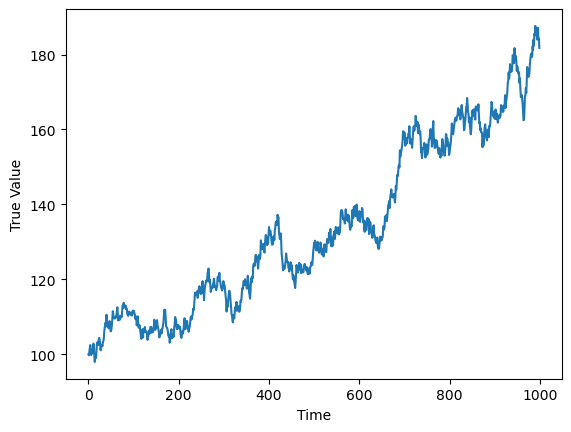

In [1106]:
#show graph
plt.plot(t,true_value)
plt.ylabel('True Value')
plt.xlabel('Time')
plt.show()

**Basic Market Maker** 
- Fixed Spread
- Estimates asset value using a simple moving average of orders


In [1107]:

prev_prices = []        #records each order price requested
order_hist = []         #records each order price aswell as buy/sell, whether it was accepted, fair value estimate, and true value
orders = []             #records all orders generated at each time step so same orders can be used for improved method
spread = 0.2            
inventory  = 0
cash = 0
fvs1 = []               #records fair value estimates at each time step
c1 = []                 #records cash at each time step
i1 = []                 #records inventory at each time step
PL1 = []                #records P&L at each time step
for i in range(len(t)):
    if len(prev_prices) >= 4:
        fair_value_estimate = np.mean(prev_prices[-4:])
        

    else: 
        fair_value_estimate = 100

    fvs1.append(fair_value_estimate)
    c1.append(cash)
    i1.append(inventory)
    PL1.append(cash + inventory * true_value[i])


    bid = fair_value_estimate - spread/2
    ask = fair_value_estimate + spread/2

    r = np.random.randint(0,5)
    temp = []
    for j in range(r):                  # make a random number of orders between 0 and 5 for each time step
        trade = order(true_value[i])
        temp.append(trade)
        order_hist.append([trade[0],trade[1],'rejected', fair_value_estimate, true_value[i]])
        if trade[1] == 'buy' and trade[0] >= ask:
            inventory += -1
            cash += ask
            prev_prices.append(trade[0])
            order_hist[-1][2] = 'accepted'

        elif trade[1] == 'sell' and trade[0] <= bid:
            inventory += 1
            cash += -bid
            prev_prices.append(trade[0])
            order_hist[-1][2] = 'accepted'

    orders.append(temp) 

PL = cash + inventory * true_value[-1]          #final P&L = cash + inventory * final true value

print(f"Cash:{cash}")
print(f"Inventory:{inventory}")
print(f"P&L:{PL}")
print(order_hist)


Cash:16502.004064996323
Inventory:-113
P&L:-4036.952476160095
[[99.90259446192705, 'buy', 'rejected', 100, 100.00000000000004], [100.18330860124884, 'sell', 'rejected', 100, 100.00000000000004], [99.90564694187007, 'buy', 'rejected', 100, 99.74179640065542], [99.95833698483807, 'buy', 'rejected', 100, 99.74179640065542], [99.8447032404475, 'buy', 'rejected', 100, 99.74179640065542], [99.81787082858122, 'sell', 'accepted', 100, 99.74179640065542], [100.76988020928862, 'buy', 'accepted', 100, 100.603963976186], [100.75038189787281, 'buy', 'accepted', 100, 100.603963976186], [101.70618849418128, 'sell', 'rejected', 100, 101.7465342945707], [101.61537639341907, 'buy', 'accepted', 100, 101.7465342945707], [102.07810769319298, 'sell', 'rejected', 100, 101.7465342945707], [101.87026282081102, 'buy', 'accepted', 100, 101.7465342945707], [102.49840826749028, 'buy', 'accepted', 101.25147533034789, 102.4834765235418], [102.46650500956531, 'buy', 'accepted', 101.25147533034789, 102.4834765235418],

**Improved Market Maker**
- Spread widens as inventory grows
- Estimates asset value using an exponentially weighted moving average of orders


In [1108]:
#Improved market maker (dynamic spread)
prev_prices = []
order_hist = []
base_spread = 0.2
k = 0.2
alpha = 0.7
inventory  = 0
cash = 0 
fair_value_estimate = 100
fvs2 = []
c2 = []
i2 = []
PL2 = []
for i in range(len(t)):
    fvs2.append(fair_value_estimate)
    c2.append(cash)
    i2.append(inventory)
    PL2.append(cash + inventory * true_value[i])
    spread = base_spread + k * abs(inventory)           #absolute value ensures that the market maker doesn't get too short aswell as too long

    bid = fair_value_estimate - spread/2
    ask = fair_value_estimate + spread/2

    
    for j in range(len(orders[i])):

        trade = orders[i][j]
        
        order_hist.append([trade[0],trade[1],'rejected', fair_value_estimate, true_value[i]])
        if trade[1] == 'buy' and trade[0] >= ask:
            inventory += -1
            cash += ask
            prev_prices.append(trade[0])
            order_hist[-1][2] = 'accepted'
            fair_value_estimate = alpha * trade[0] + (1-alpha) * fair_value_estimate

        elif trade[1] == 'sell' and trade[0] <= bid:
            inventory += 1
            cash += -bid
            prev_prices.append(trade[0])
            order_hist[-1][2] = 'accepted'
            fair_value_estimate = alpha * trade[0] + (1-alpha) * fair_value_estimate

    

PL = cash + inventory * true_value[-1]

print(f"Cash:{cash}")
print(f"Inventory:{inventory}")
print(f"P&L:{PL}")
print(order_hist)

Cash:7138.380253266293
Inventory:-51
P&L:-2131.4142918574007
[[99.90259446192705, 'buy', 'rejected', 100, 100.00000000000004], [100.18330860124884, 'sell', 'rejected', 100, 100.00000000000004], [99.90564694187007, 'buy', 'rejected', 100, 99.74179640065542], [99.95833698483807, 'buy', 'rejected', 100, 99.74179640065542], [99.8447032404475, 'buy', 'rejected', 100, 99.74179640065542], [99.81787082858122, 'sell', 'accepted', 100, 99.74179640065542], [100.76988020928862, 'buy', 'accepted', 99.87250958000685, 100.603963976186], [100.75038189787281, 'buy', 'accepted', 100.50066902050409, 100.603963976186], [101.70618849418128, 'sell', 'rejected', 100.6754680346622, 101.7465342945707], [101.61537639341907, 'buy', 'accepted', 100.6754680346622, 101.7465342945707], [102.07810769319298, 'sell', 'rejected', 101.333403885792, 101.7465342945707], [101.87026282081102, 'buy', 'accepted', 101.333403885792, 101.7465342945707], [102.49840826749028, 'buy', 'accepted', 101.70920514030531, 102.4834765235418

**Plot comparing asset true value to estimated value for both methods**

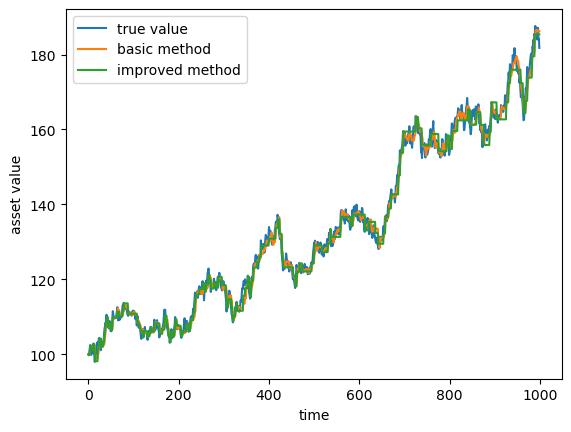

In [1109]:
plt.plot(t,true_value,label='true value')
plt.plot(t,fvs1,label='basic method')
plt.plot(t,fvs2,label='improved method')
plt.xlabel('time')
plt.ylabel('asset value')
plt.legend()
plt.show()

### Plot comparing cash at each time step
### Plot comparing inventory at each time step
- Shows the improved model being more conservative in buying/selling as inventory grows/falls 
### Plot comparing P&L at each time step
- Downward spikes in the basic model caused by having too much inventory before the value falls or vice versa

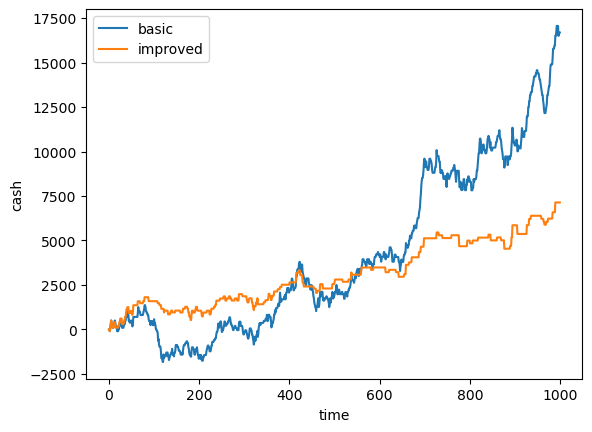

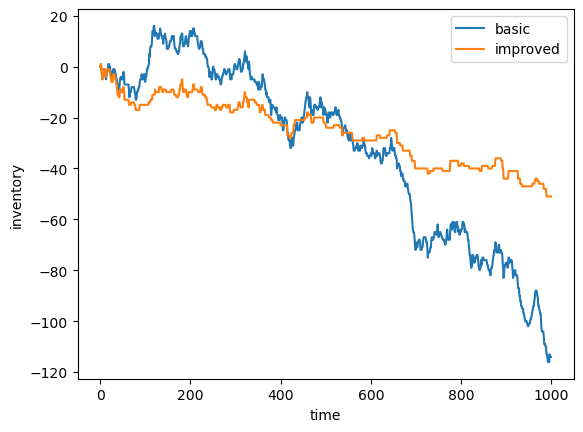

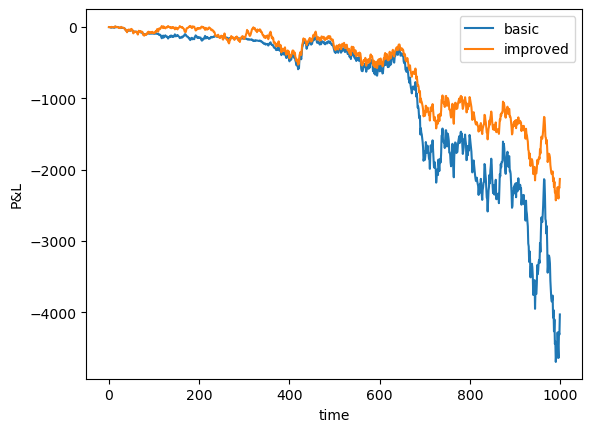

In [1110]:
plt.plot(t,c1,label='basic')
plt.plot(t,c2,label='improved')
plt.ylabel('cash')
plt.xlabel('time')
plt.legend()
plt.show()

plt.plot(t,i1,label='basic')
plt.plot(t,i2,label='improved')
plt.ylabel('inventory')
plt.xlabel('time')
plt.legend()
plt.show()

plt.plot(t,PL1,label='basic')
plt.plot(t,PL2,label='improved')
plt.ylabel('P&L')
plt.xlabel('time')
plt.legend()
plt.show()